In [1]:
# import library
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

2023-10-14 20:21:41.448497: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# load dataset with tf.keras
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()
# print shape
print(train_images.shape,train_labels.shape, test_images.shape, test_labels.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


index : 0
label :  5
image


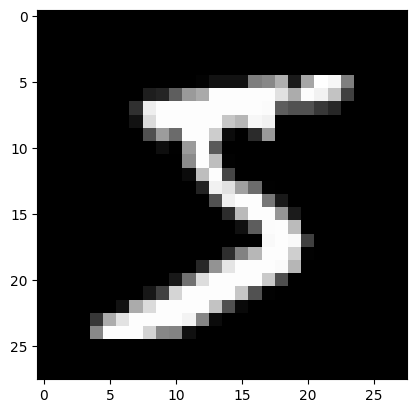

In [3]:
# check image
i = 0
print("index : " + str(i))
print("label : ", train_labels[i])
print("image")    
plt.imshow(train_images[i], cmap='gray')
plt.show()

In [4]:
# normalization
train_images = train_images/255.0
test_images = test_images/255.0

In [5]:
# input shape
input_shape=(28,28,1) # or (28,28)

In [18]:
config = [64, 'B', 'R' ,'M','Cl']

In [19]:
def make_layers(config,num_classes=10):
    layers = []
    for v in config:
        if v == 'M':
            layers += [tf.keras.layers.MaxPooling2D(pool_size=(2, 2),strides=None,padding='same')]
        elif v == 'B':
            layers += [tf.keras.layers.BatchNormalization()]
        elif v == 'R':
            layers += [tf.keras.layers.ReLU()]
        elif v == 'Cl':
            layers += [tf.keras.layers.Flatten()]
            layers += [tf.keras.layers.Dense(50, activation='relu')]
            layers += [tf.keras.layers.Dense(100, activation='relu')]
            layers += [tf.keras.layers.Dense(num_classes,activation=tf.keras.activations.softmax)]    
        else:
            layers += [tf.keras.layers.Conv2D(v,kernel_size=(3,3),strides=(1, 1),padding='same')]
    return tf.keras.models.Sequential(layers)

In [20]:
# create model
model = make_layers(config,10)

In [21]:
input_shape=(28,28,1)

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 conv2d_8 (Conv2D)           (None, 28, 28, 64)        640       
                                                                 
 batch_normalization_8 (Bat  (None, 28, 28, 64)        256       
 chNormalization)                                                
                                                                 
 re_lu_8 (ReLU)              (None, 28, 28, 64)        0         
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 flatten_2 (Flatten)         (None, 12544)             0   

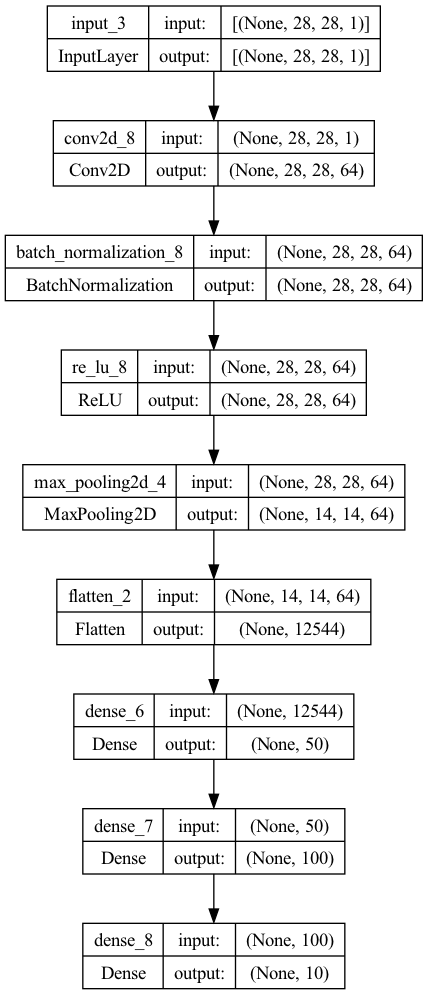

In [22]:
def get_functional_model(model):
  x = tf.keras.layers.Input(shape=(input_shape))
  model = tf.keras.Model(inputs=[x],outputs=model.call(x))
  return model

functional_model = get_functional_model(model)

functional_model.summary()
with open("model_summary.txt", "w") as fp:
    functional_model.summary(print_fn=lambda x: fp.write(x + "\r\n"))

tf.keras.utils.plot_model(functional_model, show_shapes=True, show_layer_names=True, to_file='model.png')
from IPython.display import Image
Image(retina=False, filename='model.png')

In [23]:
# define loss
loss = tf.keras.losses.SparseCategoricalCrossentropy()
# define optimizer
optimizer = tf.keras.optimizers.Adam()

In [24]:
# compile model
model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])

In [25]:
# training
history = model.fit(train_images, train_labels,epochs=3)

Epoch 1/3
1875/1875 [==============================] - 74s 39ms/step - loss: 0.1742 - accuracy: 0.9469
Epoch 2/3
1875/1875 [==============================] - 72s 38ms/step - loss: 0.0719 - accuracy: 0.9779
Epoch 3/3
1875/1875 [==============================] - 82s 44ms/step - loss: 0.0533 - accuracy: 0.9829


In [26]:
# prediction
predictions = model(test_images)

index : 0
label :  7
predictions :  7
image


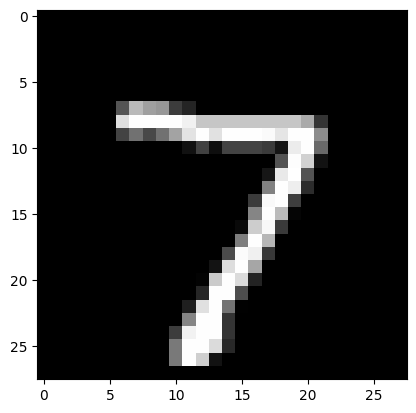

In [27]:
# check test label and prediction
i = 0
print("index : " + str(i))
print("label : ", test_labels[i])
print("predictions : ", np.argmax(predictions[i]))
print("image")    
plt.imshow(test_images[i], cmap='gray')
plt.show()